<a href="https://colab.research.google.com/github/Isaac0py/Class/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Artificial Neural Netwrok (ANN)

It is a supervised learning system buily of a large number of simple elements, called neurons or perceptrons. Each neuron can make simple decisions, and feeds those decisions to other neurons, organised in interconnected layers.

It is a machine learning algorithm that is inspired by human brain.
It is the collection of the connected neurons.

A perceptron is a single layer network

Neural network is of two types:
Shallow Neural Network: It has just one hidden layer. They are not good for learning comlex patterns.
Deep Neural Network: It has more than one hidden layer. Complex to build. It takes larger space for the storage of the model.

Activation Function (also referred to as stepp function): it is a kind of function which transfrorms a signal non-linearly.

Types of activation function:
Sigmoid
tanh
ReLU
Leaky ReLU
Maxout
ELU

Back Propagation: It is the process whereby information moves from the output layer to the input layer.

Steps of the backpropagation algorithm:
Feedforward
Calculation of error
Backpropagation of error
Adjustments weights
Repeat
Gradient Descent
Activation function
Stochastic gradient descent

Mini-batch gradient descent
Momentum
Adaptive learning rate

Optimizer: is an algorithm of function that changes the attributes of your neural network such as weights to reduce losses.

Steps for Building First ANN with TensorFlow
Data Preparation
Data Preprocessing
Add input layer
Random weight init
Add Hidden Layers
Select optimizer, loss, performance metrics
Compile model
Use model.fit to train model
Evaluate the model
Adjust optimization parameters or model if needed

In [2]:
pip python -m pip install tensorflow

ERROR: unknown command "python"


In [3]:
pip install tensorflow

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
dataset = pd.read_csv('/content/drive/MyDrive/CSV/Customer_Churn_Modelling.csv')

In [7]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
X = dataset.iloc[:,3:-1]
y = dataset['Exited']

<Axes: xlabel='Exited', ylabel='count'>

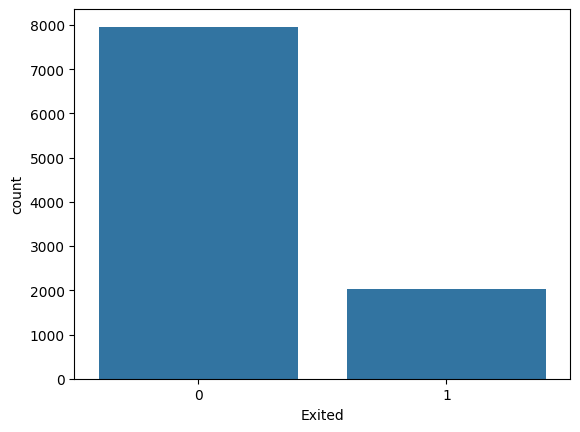

In [9]:
sns.countplot(x=y)

In [10]:
X.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

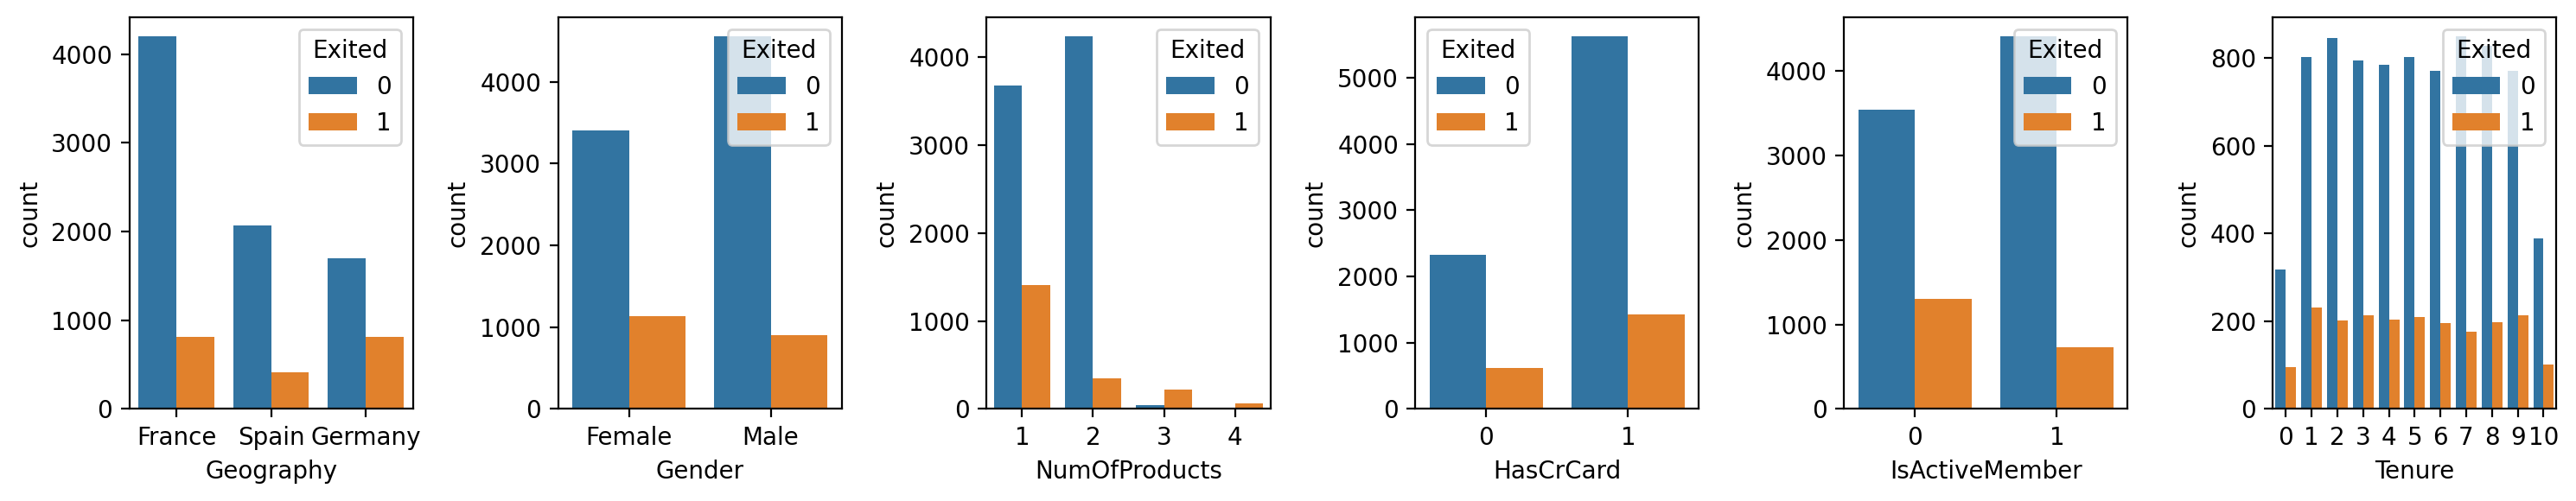

In [11]:
plt.rcParams['figure.figsize'] = (15,3)
plt.rcParams['figure.dpi'] = 200

fig,ax = plt.subplots(1,6)
sns.countplot(x='Geography',data=X,ax=ax[0], hue=y)
sns.countplot(x='Gender',data=X,ax=ax[1], hue=y)
sns.countplot(x='NumOfProducts',data=X,ax=ax[2], hue=y)
sns.countplot(x='HasCrCard',data=X,ax=ax[3], hue=y)
sns.countplot(x='IsActiveMember',data=X,ax=ax[4], hue=y)
sns.countplot(x='Tenure',data=X,ax=ax[5], hue=y)

plt.tight_layout()

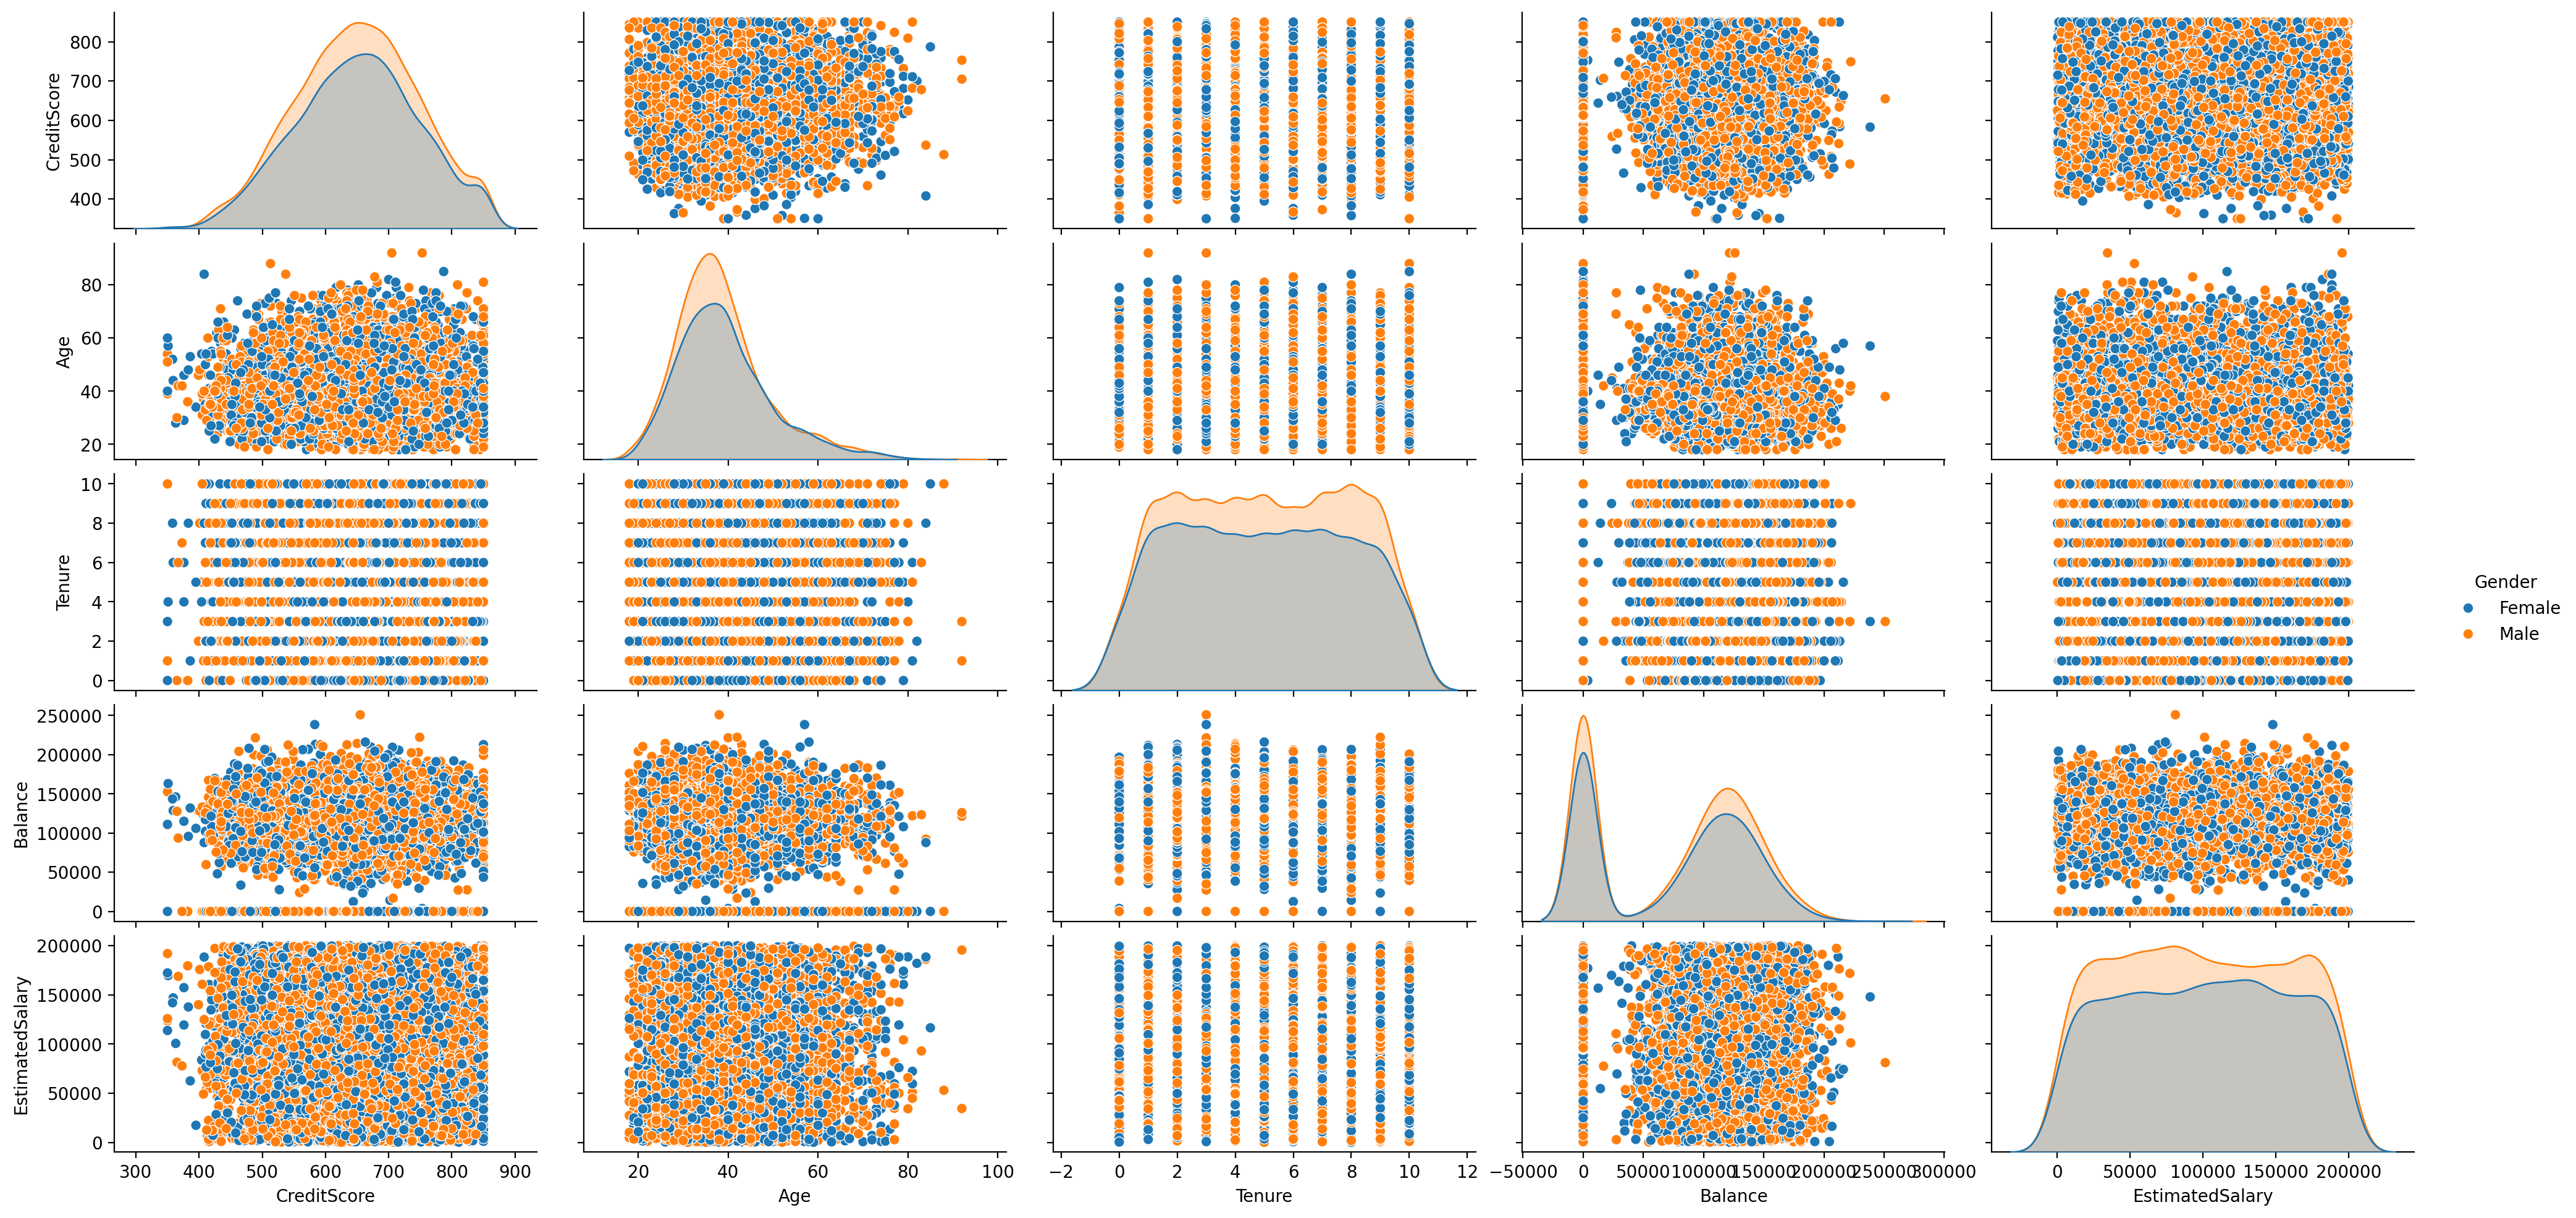

In [12]:
sns.pairplot(dataset, vars=['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary'], hue='Gender', height=2, aspect=2)

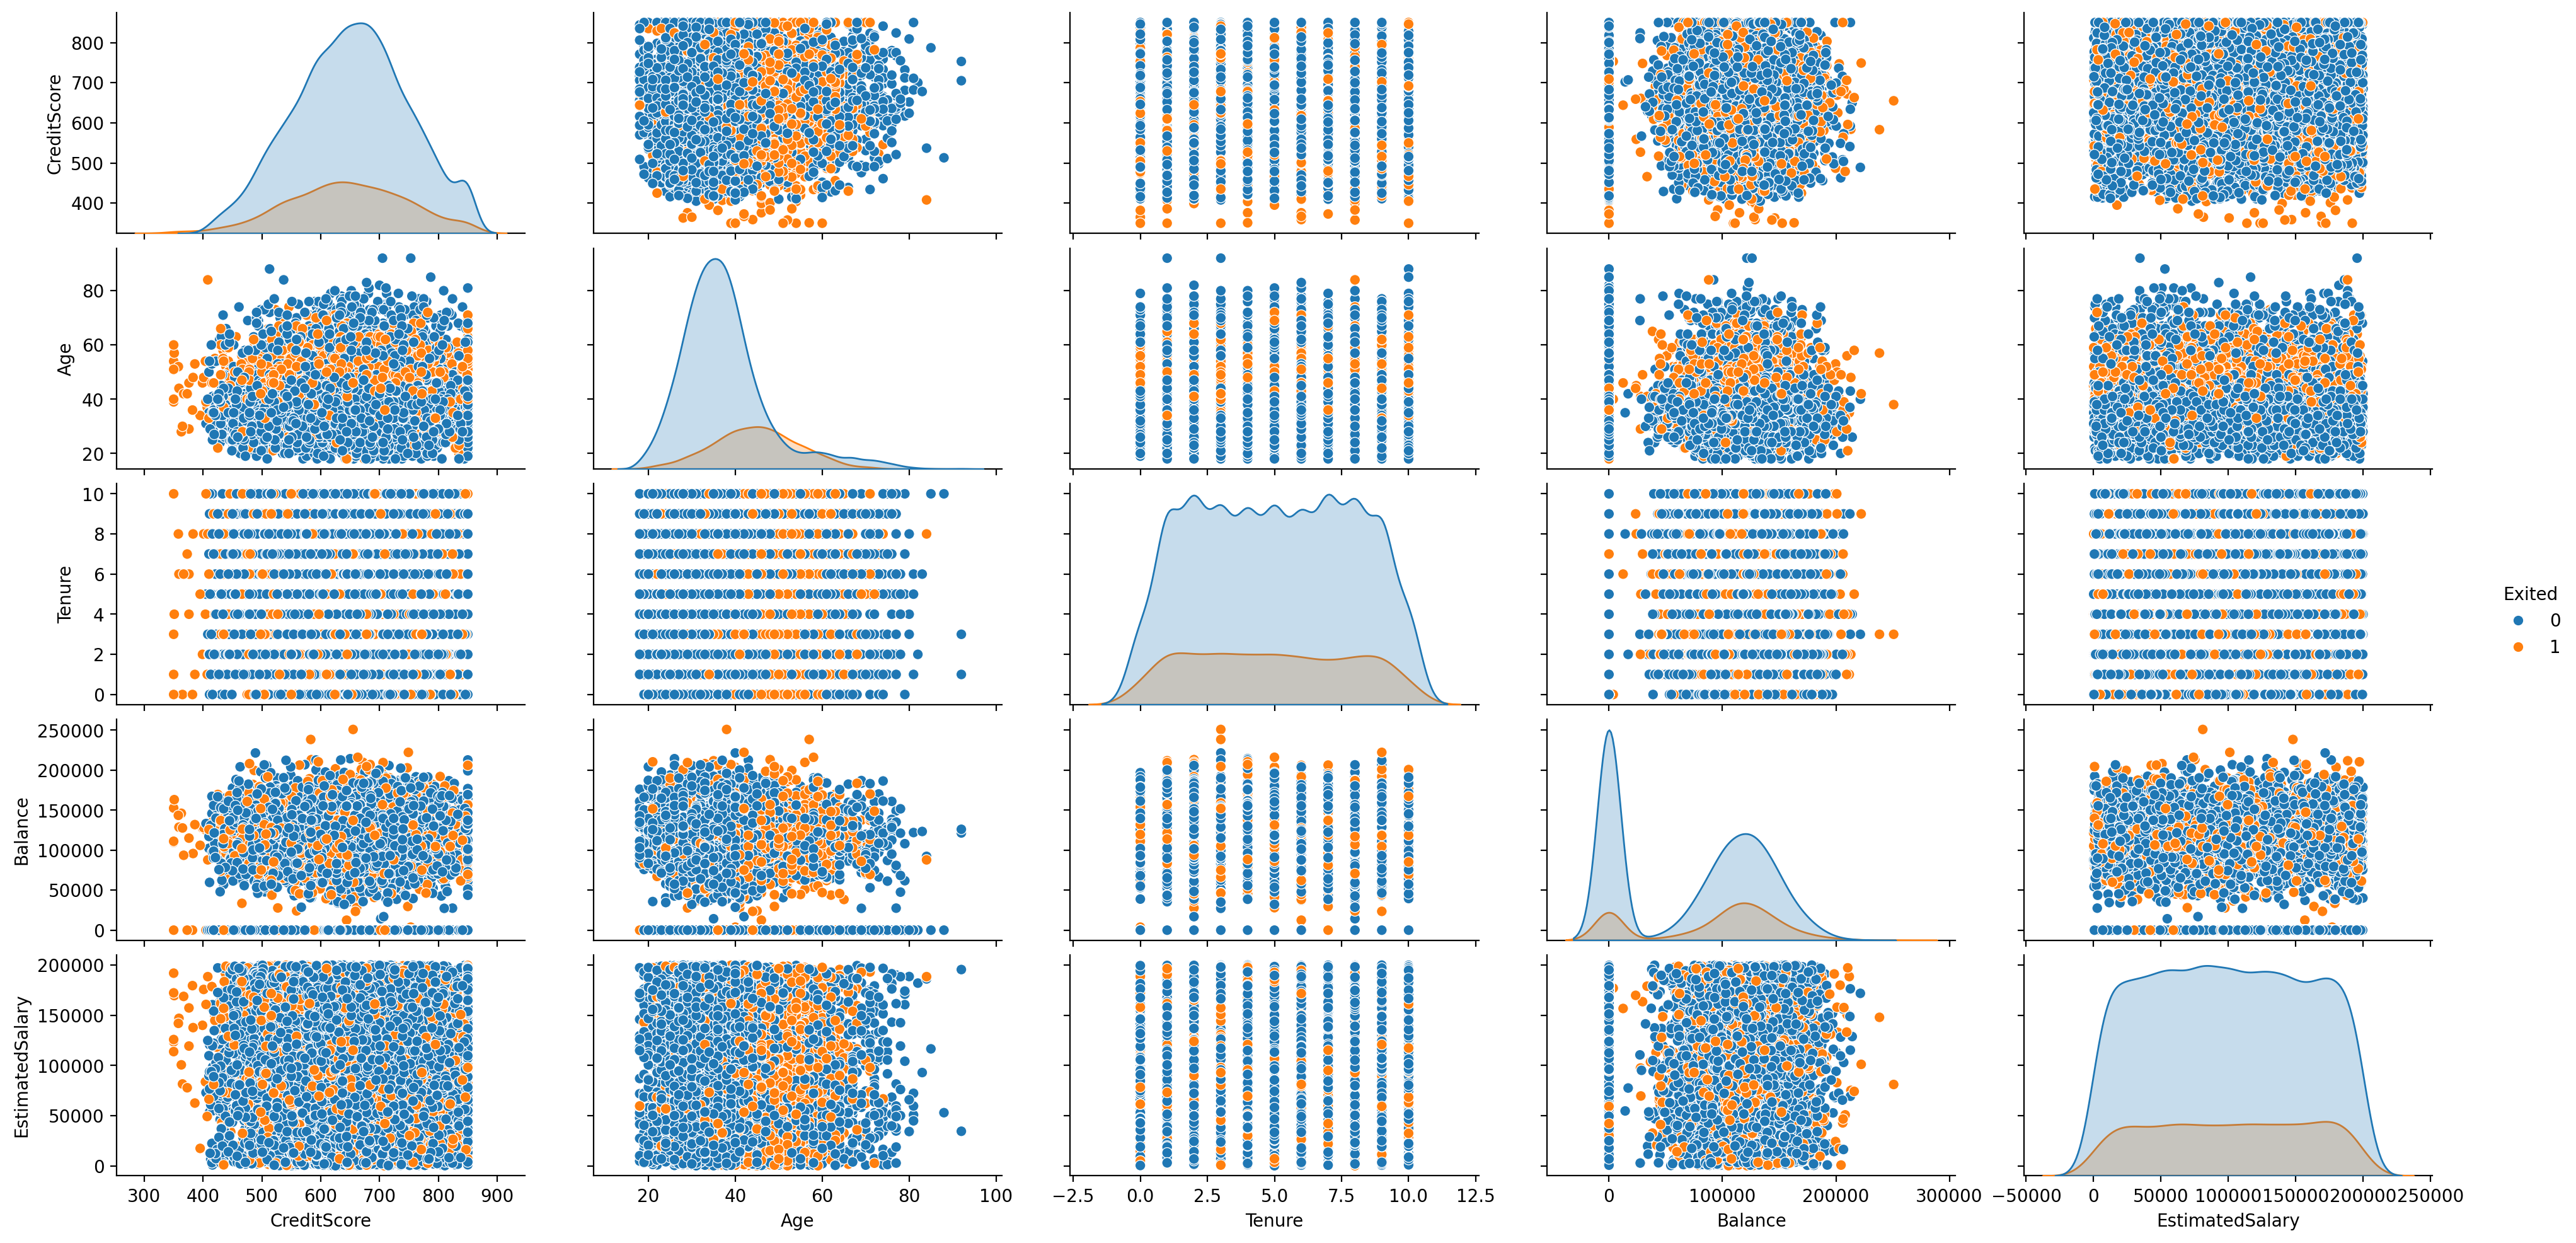

In [13]:
sns.pairplot(dataset, vars=['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary'], hue='Exited', height=2, aspect=2)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
X_onehot = pd.get_dummies(X, drop_first=True)

X_onehot = X_onehot.map(lambda x: 1 if x is True else (0 if x is False else x))
X_onehot.tail()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1
9999,792,28,4,130142.79,1,1,0,38190.78,0,0,0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_onehot, y, test_size=0.2, random_state=42, stratify = y)

In [23]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

**Build Neural Network Model**

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, InputLayer

from tensorflow.keras.optimizers import Adam

In [26]:
input_shape = X_train.shape[1:]

In [30]:
class_weight = y.value_counts().to_dict()
class_weight

{0: 7963, 1: 2037}

In [34]:
total_sample = sum(class_weight.values())
total_sample

class_weight = total_sample/(len(class_weight)*class_weight[0]), total_sample/(len(class_weight)*class_weight[1])

(0.6279040562602034, 2.454590083456063)

In [36]:
model = Sequential()
model.add(InputLayer(input_shape))
model.add(Dense(128, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,177 (71.00 KB)

 Trainable params: 18,177 (71.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
sum([11*128+128, 128*128+128, 1*128+1])

18177

In [42]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [43]:
class_weight = {0:0.6279040562602034, 1:2.454590083456063}

In [46]:
history = model.fit(X_train, y_train, batch_size=32, epochs=10, class_weight=class_weight, validation_split=0.1)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8325 - loss: 0.3709 - val_accuracy: 0.8188 - val_loss: 0.3740
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8232 - loss: 0.3731 - val_accuracy: 0.8275 - val_loss: 0.3603
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8382 - loss: 0.3480 - val_accuracy: 0.8413 - val_loss: 0.3478
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8371 - loss: 0.3652 - val_accuracy: 0.8200 - val_loss: 0.3730
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8346 - loss: 0.3435 - val_accuracy: 0.8238 - val_loss: 0.3638
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8426 - loss: 0.3497 - val_accuracy: 0.8163 - val_loss: 0.3898
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8435 - loss: 0.3319 - val_accuracy: 0.8350 - val_loss: 0.3549
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8470 - loss: 0.3297 - val_accuracy: 0

<Axes: >

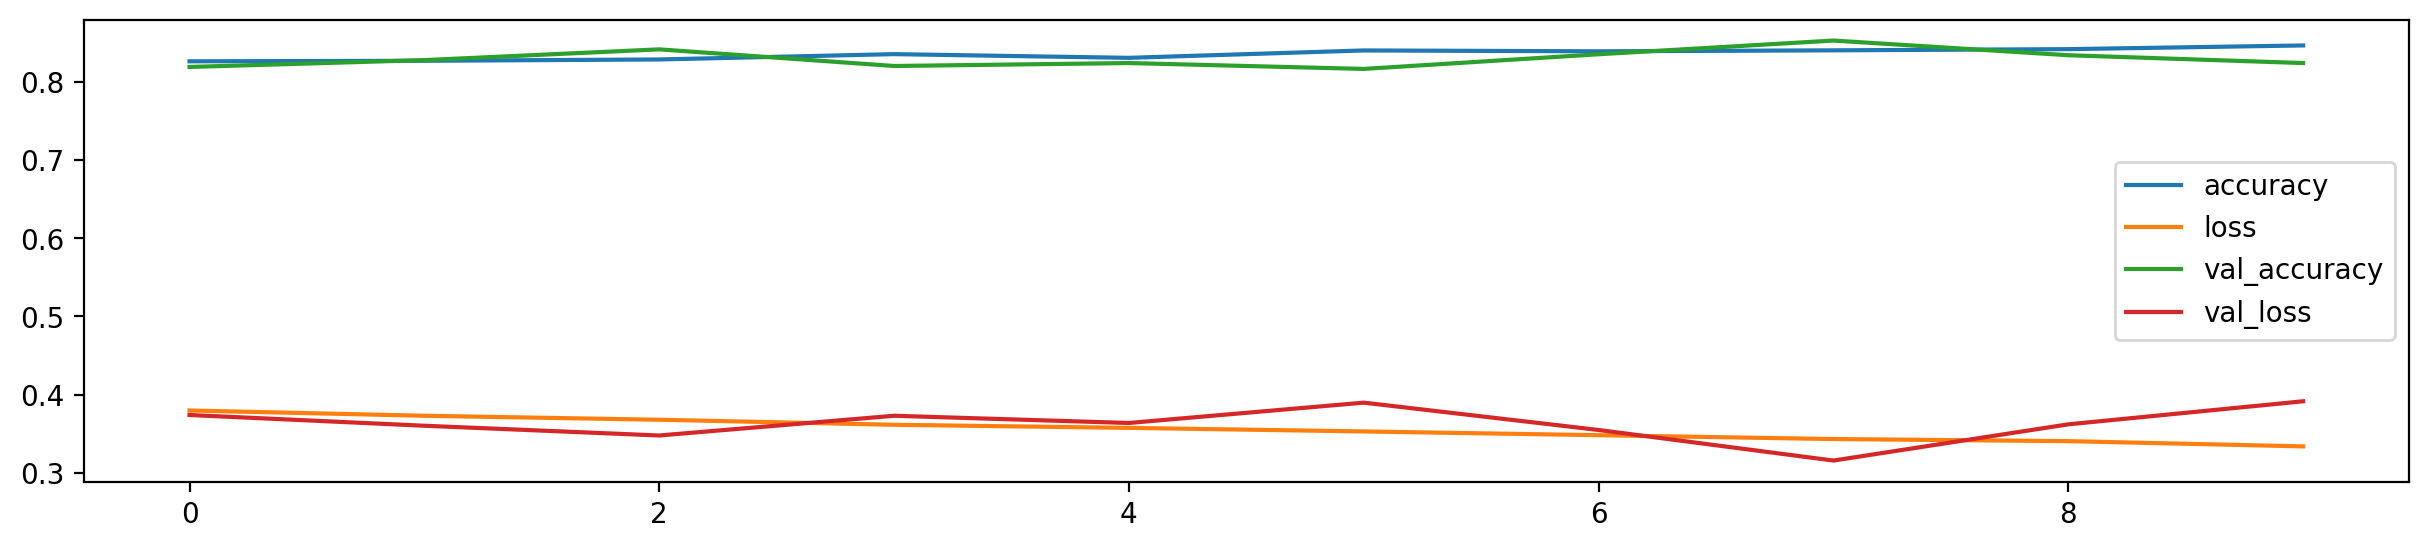

In [50]:
hist = pd.DataFrame(history.history)
hist.plot()

In [51]:
from sklearn.metrics import classification_report

In [52]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [53]:
y_pred

array([[0.040299  ],
       [0.01292303],
       [0.0253044 ],
       ...,
       [0.9700452 ],
       [0.01159201],
       [0.4967086 ]], dtype=float32)

In [55]:
y_pred = (y_pred>0.5).astype(int)

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.78      0.85      1593
           1       0.47      0.73      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.76      0.71      2000
weighted avg       0.83      0.77      0.79      2000



**Model Saved and Load**

In [57]:
import pickle
import os

In [62]:
os.makedirs('model', exist_ok=True)

In [63]:
model.save('model/churn_model.h5')

In [65]:
pickle.dump(scaler, open('model/scaler.pkl', 'wb'))

In [66]:
model1= keras.models.load_model('model/churn_model.h5')
scaler1 = pickle.load(open('model/scaler.pkl', 'rb'))

In [69]:
X_onehot.columns


Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [68]:
X_test[0]

array([-0.68073539, -0.27993196,  0.68472287, -1.22605881,  0.80883036,
        0.64104192, -1.030206  , -0.09502138, -0.57831252, -0.57773517,
        0.90750738])

In [74]:
test = list(X_onehot.iloc[0].values)
test

[np.float64(619.0),
 np.float64(42.0),
 np.float64(2.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(101348.88),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

In [106]:
test = [600.0, 32.0, 2.0, 0.0, 1.0, 1.0, 1.0, 101348.88, 0.0, 0.0, 1]
test = scaler.transform([test])
test

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.52544045, -0.65993547, -1.04143297, -1.22605881, -0.91025649,
         0.64104192,  0.97067965,  0.02822301, -0.57831252, -0.57773517,
         0.90750738]])

In [107]:
import numpy as np
(model.predict(test)>0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[0]])